In [2]:
from nnscf import device, criterion, NNSCFMapper
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import os
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [3]:
samples_per_L = 10000

# Hyperparameters
epochs = 100
# using 0.001 for Adam and 0.01 for LBFGS as default values
lr = 0.05

# Data splitting
# ! make sure that the splitting is the same as in renormalization.ipynb
data_size = 100
train_size = 70
val_size = 10

raw_dir = "./raw/"
relev_dir = "./relev/"
norm_dir = "./norm/"
os.makedirs(norm_dir, exist_ok=True)

In [3]:
def normalize_new(raw, limits):
    min, max = limits
    norm = 2.0 * ((raw - min) / (max - min)) - 1.0 if max != min else raw
    return norm

In [4]:
class OldOFDMDataset(Dataset, ):
    def __init__(self, pt_folder_path, part):
        self.folder_path = pt_folder_path
        self.part = part

    def __len__(self):
        return data_size # Assuming exactly data_size pre-computed .pt files, regardless of train/test split

    def __getitem__(self, idx):
        # Instantly loads the pre-normalized tensors directly into memory!
        file_path = os.path.join(self.folder_path, f"old_method_{idx:02d}_{self.part}.pt")
        # Load the dictionary
        data_pkg = torch.load(file_path, weights_only=False)

        # Return the tensors AND the scaling limits
        return (data_pkg['X_norm'], data_pkg['Y_norm'],
                data_pkg['X_min'], data_pkg['X_max'],
                data_pkg['Y_min'], data_pkg['Y_max'])

class NewOFDMDataset(Dataset):
    def __init__(self, pt_folder_path, part):
        self.folder_path = pt_folder_path
        self.part = part

    def __len__(self):
        return data_size # Assuming exactly data_size pre-computed .pt files, regardless of train/test split

    def __getitem__(self, idx):
        # Instantly loads the pre-normalized tensors directly into memory!
        file_path = os.path.join(self.folder_path, f"new_method_{idx:02d}_{self.part}.pt")
        # Load the dictionary
        data_pkg = torch.load(file_path, weights_only=False)

        # Return the tensors AND the scaling limits
        return (data_pkg['X_norm'], data_pkg['Y_norm'])

In [5]:
lims = torch.load(os.path.join(relev_dir, f"new_method_raw_limits.pt"), weights_only=False)
X_r_limits = (min(lims["X_r_min"][:train_size]), max(lims["X_r_max"][:train_size]))
Y_r_limits = (min(lims["Y_r_min"][:train_size]), max(lims["Y_r_max"][:train_size]))
X_i_limits = (min(lims["X_i_min"][:train_size]), max(lims["X_i_max"][:train_size]))
Y_i_limits = (min(lims["Y_i_min"][:train_size]), max(lims["Y_i_max"][:train_size]))

before_loop = time.time()
for i in range(data_size):
    loop_start = time.time() if i else before_loop

    real_path_raw = os.path.join(raw_dir, f"new_method_{i:02d}_real.pt")
    imag_path_raw = os.path.join(raw_dir, f"new_method_{i:02d}_imag.pt")

    data_real = torch.load(real_path_raw, weights_only=True)
    data_imag = torch.load(imag_path_raw, weights_only=True)

    X_r_norm = normalize_new(data_real['X_raw'], X_r_limits)
    Y_r_norm = normalize_new(data_real['Y_raw'], Y_r_limits)
    X_i_norm = normalize_new(data_imag['X_raw'], X_i_limits)
    Y_i_norm = normalize_new(data_imag['Y_raw'], X_i_limits)

    torch.save({
        'X_norm': X_r_norm,
        'Y_norm': Y_r_norm
    }, os.path.join(norm_dir, f"new_method_{i:02d}_real.pt"))

    torch.save({
        'X_norm': X_i_norm,
        'Y_norm': Y_i_norm
    }, os.path.join(norm_dir, f"new_method_{i:02d}_imag.pt"))

    loop_end = time.time()
    print(f"Iteration {i + 1}/{data_size} completed in {loop_end - loop_start:.2f} seconds")
    print(f"{loop_end - before_loop:.2f} seconds passed since before loop start")

Iteration 1/100 completed in 0.60 seconds
0.60 seconds passed since before loop start
Iteration 2/100 completed in 0.48 seconds
1.09 seconds passed since before loop start
Iteration 3/100 completed in 0.49 seconds
1.57 seconds passed since before loop start
Iteration 4/100 completed in 0.47 seconds
2.05 seconds passed since before loop start
Iteration 5/100 completed in 0.50 seconds
2.55 seconds passed since before loop start
Iteration 6/100 completed in 0.57 seconds
3.12 seconds passed since before loop start
Iteration 7/100 completed in 0.51 seconds
3.63 seconds passed since before loop start
Iteration 8/100 completed in 0.48 seconds
4.11 seconds passed since before loop start
Iteration 9/100 completed in 0.46 seconds
4.57 seconds passed since before loop start
Iteration 10/100 completed in 0.47 seconds
5.04 seconds passed since before loop start
Iteration 11/100 completed in 0.49 seconds
5.53 seconds passed since before loop start
Iteration 12/100 completed in 0.50 seconds
6.03 seco

In [5]:
# todo: make edits so that it works if using one batch
# fixme: find alternative shuffling technique
# Configuration

# Initialize DataLoaders with asynchronous loading (num_workers) and rapid memory transfer
dataset_real_old = OldOFDMDataset(norm_dir, part='real')
dataset_imag_old = OldOFDMDataset(norm_dir, part='imag')

# Use the first train_size files for training
train_dataset_real_old = Subset(dataset_real_old, range(train_size))
train_dataset_imag_old = Subset(dataset_imag_old, range(train_size))

# Use the middle val_size files for validation
val_dataset_real_old = Subset(dataset_real_old, range(train_size, train_size + val_size))
val_dataset_imag_old = Subset(dataset_imag_old, range(train_size, train_size + val_size))

# ? should i change batch_size in the new architecture
train_loader_real_old = DataLoader(
    train_dataset_real_old,
    batch_size=None,  # batch_size is None because the dataset returns a full batch of 10,000
    shuffle=True,
    # ! does not work locally on windows when changed to 2-4 for some reason
    num_workers=0,  # Adjust between 2-4 based on your CPU cores
    pin_memory=torch.cuda.is_available()
)
train_loader_imag_old = DataLoader(
    train_dataset_imag_old,
    batch_size=None,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader_real_old = DataLoader(
    val_dataset_real_old,
    batch_size=None,  # batch_size is None because the dataset returns a full batch of 10,000
    shuffle=False,
    # ! does not work locally on windows when changed to 2-4 for some reason
    num_workers=0,  # Adjust between 2-4 based on your CPU cores
    pin_memory=torch.cuda.is_available()
)
val_loader_imag_old = DataLoader(
    val_dataset_imag_old,
    batch_size=None,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# Initialize models and send them to the GPU/device
Old_Re_NN = NNSCFMapper().to(device)
Old_Im_NN = NNSCFMapper().to(device)

optimizer_real_old = optim.LBFGS(Old_Re_NN.parameters(), lr=lr, tolerance_change=1e-5, max_iter=5)
optimizer_imag_old = optim.LBFGS(Old_Im_NN.parameters(), lr=lr, tolerance_change=1e-5, max_iter=5)

In [7]:
# todo: make edits so that it works if using one batch
# fixme: find alternative shuffling technique
# Configuration

# Initialize DataLoaders with asynchronous loading (num_workers) and rapid memory transfer
dataset_real_new = NewOFDMDataset(norm_dir, part='real')
dataset_imag_new = NewOFDMDataset(norm_dir, part='imag')

# Use the first train_size files for training
train_dataset_real_new = Subset(dataset_real_new, range(train_size))
train_dataset_imag_new = Subset(dataset_imag_new, range(train_size))

# Use the middle val_size files for validation
val_dataset_real_new = Subset(dataset_real_new, range(train_size, train_size + val_size))
val_dataset_imag_new = Subset(dataset_imag_new, range(train_size, train_size + val_size))

# ? should i change batch_size in the new architecture
train_loader_real_new = DataLoader(
    train_dataset_real_new,
    batch_size=None, # batch_size is None because the dataset returns a full batch of 10,000
    shuffle=True,
    # ! does not work locally on windows when changed to 2-4 for some reason
    num_workers=0,   # Adjust between 2-4 based on your CPU cores
    pin_memory=torch.cuda.is_available()
)
train_loader_imag_new = DataLoader(
    train_dataset_imag_new,
    batch_size=None,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader_real_new = DataLoader(
    val_dataset_real_new,
    batch_size=None, # batch_size is None because the dataset returns a full batch of 10,000
    shuffle=False,
    # ! does not work locally on windows when changed to 2-4 for some reason
    num_workers=0,   # Adjust between 2-4 based on your CPU cores
    pin_memory=torch.cuda.is_available()
)
val_loader_imag_new = DataLoader(
    val_dataset_imag_new,
    batch_size=None,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# Initialize models and send them to the GPU/device
New_Re_NN = NNSCFMapper().to(device)
New_Im_NN = NNSCFMapper().to(device)

optimizer_real_new = optim.LBFGS(New_Re_NN.parameters(), lr=lr, tolerance_change=1e-5, max_iter=5)
optimizer_imag_new = optim.LBFGS(New_Im_NN.parameters(), lr=lr, tolerance_change=1e-5, max_iter=5)

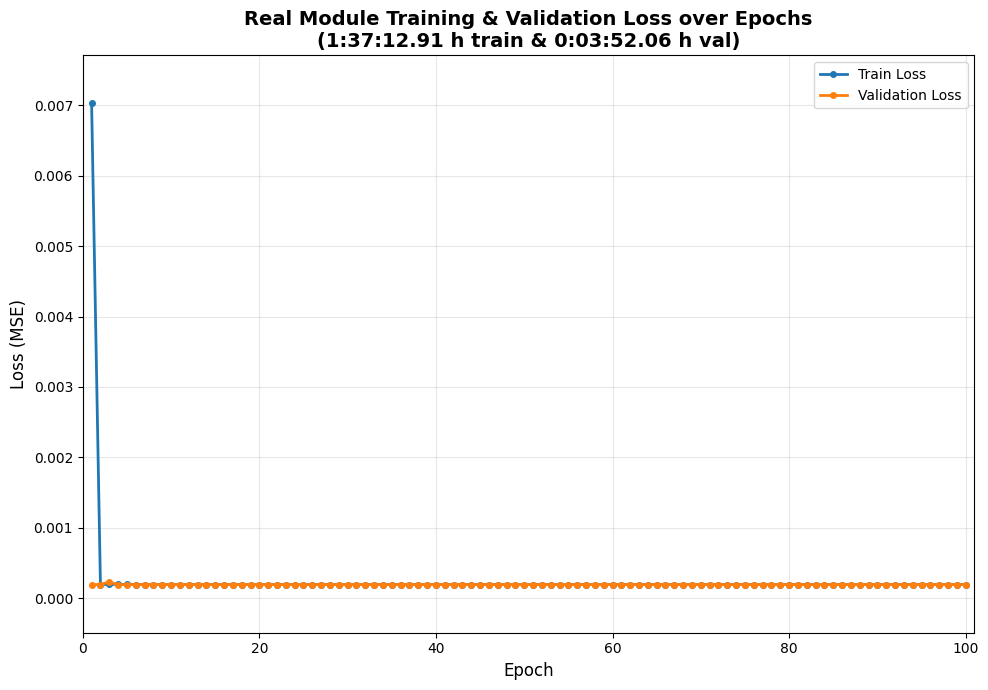

Real Module | Epoch 1/100 | Train Loss: 0.007027 | Val Loss 0.000194 | Time: 107.24 seconds
Real Module | Epoch 2/100 | Train Loss: 0.000194 | Val Loss 0.000193 | Time: 63.68 seconds
Real Module | Epoch 3/100 | Train Loss: 0.000196 | Val Loss 0.000230 | Time: 63.24 seconds
Real Module | Epoch 4/100 | Train Loss: 0.000197 | Val Loss 0.000192 | Time: 66.20 seconds
Real Module | Epoch 5/100 | Train Loss: 0.000196 | Val Loss 0.000192 | Time: 65.41 seconds
Real Module | Epoch 6/100 | Train Loss: 0.000193 | Val Loss 0.000192 | Time: 62.70 seconds
Real Module | Epoch 7/100 | Train Loss: 0.000193 | Val Loss 0.000192 | Time: 60.90 seconds
Real Module | Epoch 8/100 | Train Loss: 0.000193 | Val Loss 0.000192 | Time: 60.62 seconds
Real Module | Epoch 9/100 | Train Loss: 0.000193 | Val Loss 0.000192 | Time: 60.64 seconds
Real Module | Epoch 10/100 | Train Loss: 0.000193 | Val Loss 0.000192 | Time: 62.94 seconds
Real Module | Epoch 11/100 | Train Loss: 0.000193 | Val Loss 0.000192 | Time: 69.93 seco

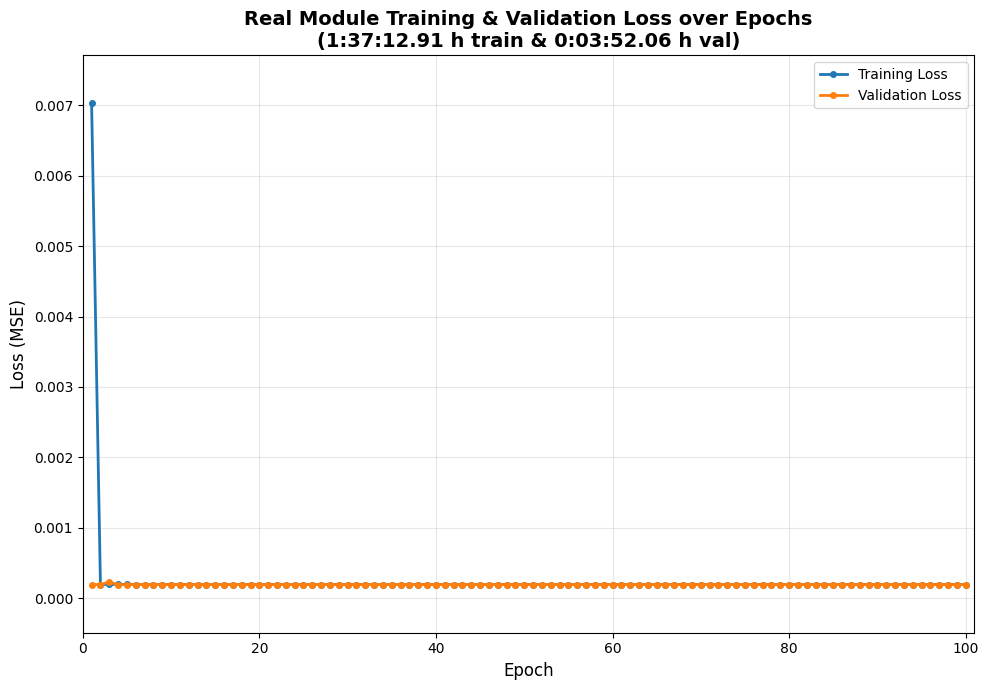

In [8]:
print("--- Starting Training for the Real NN Module ---")
train_loss_history = []  # Track losses for graphing
val_loss_history = []
log_lines = []
total_time = 0
train_time = 0
val_time = 0

# ! if using .compile(), it is expected for the first epoch to take longer
for epoch in range(1, epochs + 1):
    start = time.time()
    epoch_train_loss = 0.0

    # Training
    Old_Re_NN.train()
    for X_batch, Y_batch, _, _, _, _ in train_loader_real_old:
        # Transfer data to GPU if possible
        X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)

        # MEMORYLESS RESHAPE: Flatten into a 1D column
        X_batch_flat = X_batch.view(-1, 1)
        Y_batch_flat = Y_batch.view(-1, 1)

        # L-BFGS and LM require a "closure" function to recalculate the loss, but for LM it is often required to return the unreduced residuals
        def closure():
            optimizer_real_old.zero_grad(set_to_none=True)
            predictions = Old_Re_NN(X_batch_flat)

            loss = criterion(predictions, Y_batch_flat)
            loss.backward()
            return loss
        # Pass the closure to the optimizer
        optimizer_real_old.step(closure)
        # To track the loss for your graphs, you have to call it once outside
        epoch_train_loss += closure().item()

    avg_train_loss = epoch_train_loss / len(train_loader_real_old)
    train_loss_history.append(avg_train_loss)  # Store loss for this epoch

    middle = time.time()

    # Validation
    Old_Re_NN.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for X_val, Y_val, _, _, _, _ in val_loader_real_old:
            X_val, Y_val = X_val.to(device, non_blocking=True), Y_val.to(device, non_blocking=True)
            predictions = Old_Re_NN(X_val.view(-1, 1))
            val_loss = criterion(predictions, Y_val.view(-1, 1))
            epoch_val_loss += val_loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader_real_old)
    val_loss_history.append(avg_val_loss)

    end = time.time()

    train_time += middle - start
    val_time += end - middle
    total_time += end - start
    line = f'Real Module | Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss {avg_val_loss:.6f} | Time: {end - start:.2f} seconds'
    log_lines.append(line)

    if epoch % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(10, 7))
        plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Train Loss")
        plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Validation Loss")
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss (MSE)', fontsize=12)
        plt.legend()
        plt.title(f'Real Module Training & Validation Loss over Epochs\n({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} h train & {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} h val)', fontsize=14, fontweight='bold')
        plt.xlim(0, epochs + 1)
        margin = (max(train_loss_history) - min(train_loss_history)) * 0.1 if len(train_loss_history) > 1 else 0.1
        plt.ylim(min(train_loss_history) - margin, max(train_loss_history) + margin)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(*log_lines, sep='\n')
    else:
        print(line)


print(f'Real NN Module Training Complete in {int(total_time // 3600)}:{int(total_time // 60 % 60):02}:{total_time % 60:05.2f} hours! ({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} hours in training and {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} hours in validation)')

# Plot loss vs epoch
plt.figure(figsize=(10, 7))
plt.plot(range(1, epochs + 1), train_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Training Loss")
plt.plot(range(1, epochs + 1), val_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Validation Loss")
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.title(f'Real Module Training & Validation Loss over Epochs\n({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} h train & {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} h val)', fontsize=14, fontweight='bold')
plt.xlim(0, epochs + 1)
margin = (max(train_loss_history) - min(train_loss_history)) * 0.1
plt.ylim(min(train_loss_history) - margin, max(train_loss_history) + margin)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(relev_dir, f"old_method_real_loss.png"), dpi=150)
plt.show()

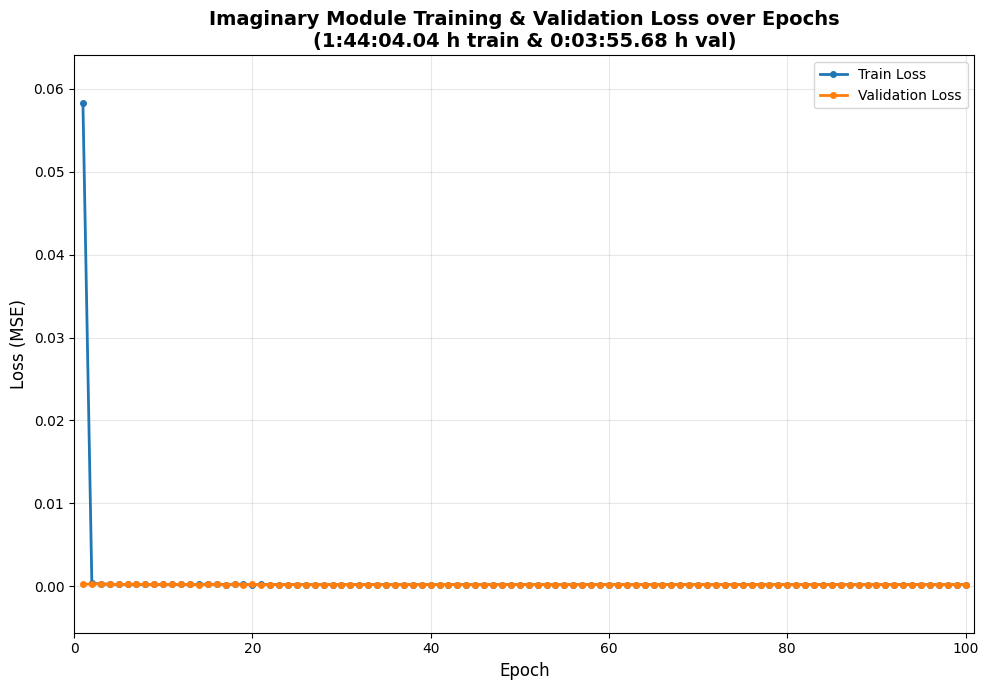

Imaginary Module | Epoch 1/100 | Train Loss: 0.058242 | Val Loss 0.000230 | Time: 141.64 seconds
Imaginary Module | Epoch 2/100 | Train Loss: 0.000374 | Val Loss 0.000280 | Time: 84.69 seconds
Imaginary Module | Epoch 3/100 | Train Loss: 0.000263 | Val Loss 0.000283 | Time: 76.63 seconds
Imaginary Module | Epoch 4/100 | Train Loss: 0.000241 | Val Loss 0.000240 | Time: 83.99 seconds
Imaginary Module | Epoch 5/100 | Train Loss: 0.000229 | Val Loss 0.000218 | Time: 80.64 seconds
Imaginary Module | Epoch 6/100 | Train Loss: 0.000218 | Val Loss 0.000218 | Time: 62.47 seconds
Imaginary Module | Epoch 7/100 | Train Loss: 0.000219 | Val Loss 0.000250 | Time: 63.46 seconds
Imaginary Module | Epoch 8/100 | Train Loss: 0.000222 | Val Loss 0.000213 | Time: 74.85 seconds
Imaginary Module | Epoch 9/100 | Train Loss: 0.000213 | Val Loss 0.000213 | Time: 63.15 seconds
Imaginary Module | Epoch 10/100 | Train Loss: 0.000213 | Val Loss 0.000213 | Time: 60.02 seconds
Imaginary Module | Epoch 11/100 | Trai

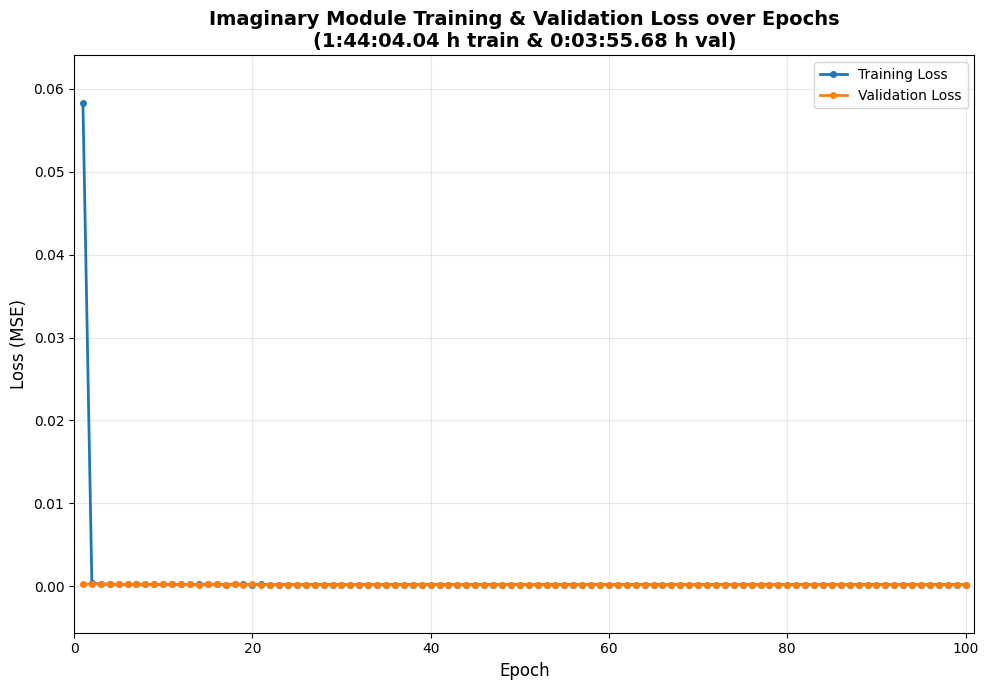

In [9]:
print("--- Starting Training for the Imaginary NN Module ---")
train_loss_history = []  # Track losses for graphing
val_loss_history = []
log_lines = []
total_time = 0
train_time = 0
val_time = 0

for epoch in range(1, epochs + 1):
    start = time.time()

    # Training
    Old_Im_NN.train()
    epoch_train_loss = 0.0
    for X_batch, Y_batch, _, _, _, _ in train_loader_imag_old:
        # Transfer data to GPU if possible
        X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)

        # MEMORYLESS RESHAPE: Flatten into a 1D column
        X_batch_flat = X_batch.view(-1, 1)
        Y_batch_flat = Y_batch.view(-1, 1)

        # L-BFGS and LM require a "closure" function to recalculate the loss, but for LM it is often required to return the unreduced residuals
        def closure():
            optimizer_imag_old.zero_grad(set_to_none=True)
            predictions = Old_Im_NN(X_batch_flat)

            loss = criterion(predictions, Y_batch_flat)
            loss.backward()
            return loss
        # Pass the closure to the optimizer
        optimizer_imag_old.step(closure)
        # To track the loss for your graphs, you have to call it once outside
        epoch_train_loss += closure().item()

    avg_train_loss = epoch_train_loss / len(train_loader_imag_old)
    train_loss_history.append(avg_train_loss)  # Store loss for this epoch

    middle = time.time()

    # Validation
    Old_Im_NN.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for X_val, Y_val, _, _, _, _ in val_loader_imag_old:
            X_val, Y_val = X_val.to(device, non_blocking=True), Y_val.to(device, non_blocking=True)
            predictions = Old_Im_NN(X_val.view(-1, 1))
            val_loss = criterion(predictions, Y_val.view(-1, 1))
            epoch_val_loss += val_loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader_imag_old)
    val_loss_history.append(avg_val_loss)

    end = time.time()

    train_time += middle - start
    val_time += end - middle
    total_time += end - start
    line = f'Imaginary Module | Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss {avg_val_loss:.6f} | Time: {end - start:.2f} seconds'
    log_lines.append(line)

    if epoch % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(10, 7))
        plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Train Loss")
        plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Validation Loss")
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss (MSE)', fontsize=12)
        plt.legend()
        plt.title(f'Imaginary Module Training & Validation Loss over Epochs\n({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} h train & {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} h val)', fontsize=14, fontweight='bold')
        plt.xlim(0, epochs + 1)
        margin = (max(train_loss_history) - min(train_loss_history)) * 0.1 if len(train_loss_history) > 1 else 0.1
        plt.ylim(min(train_loss_history) - margin, max(train_loss_history) + margin)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(*log_lines, sep='\n')
    else:
        print(line)


print(f'Imaginary NN Module Training Complete in {int(total_time // 3600)}:{int(total_time // 60 % 60):02}:{total_time % 60:05.2f} hours! ({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} hours in training and {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} hours in validation)')

# Plot loss vs epoch
plt.figure(figsize=(10, 7))
plt.plot(range(1, epochs + 1), train_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Training Loss")
plt.plot(range(1, epochs + 1), val_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Validation Loss")
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.title(f'Imaginary Module Training & Validation Loss over Epochs\n({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} h train & {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} h val)', fontsize=14, fontweight='bold')
plt.xlim(0, epochs + 1)
margin = (max(train_loss_history) - min(train_loss_history)) * 0.1
plt.ylim(min(train_loss_history) - margin, max(train_loss_history) + margin)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(relev_dir, f"old_method_imag_loss.png"), dpi=150)
plt.show()

In [11]:
# Save the trained models
torch.save(Old_Re_NN.state_dict(), os.path.join(relev_dir, f"old_method_weights_re.pth"))
torch.save(Old_Im_NN.state_dict(), os.path.join(relev_dir, f"old_method_weights_im.pth"))
print("\nTraining complete and weights saved!")


Training complete and weights saved!


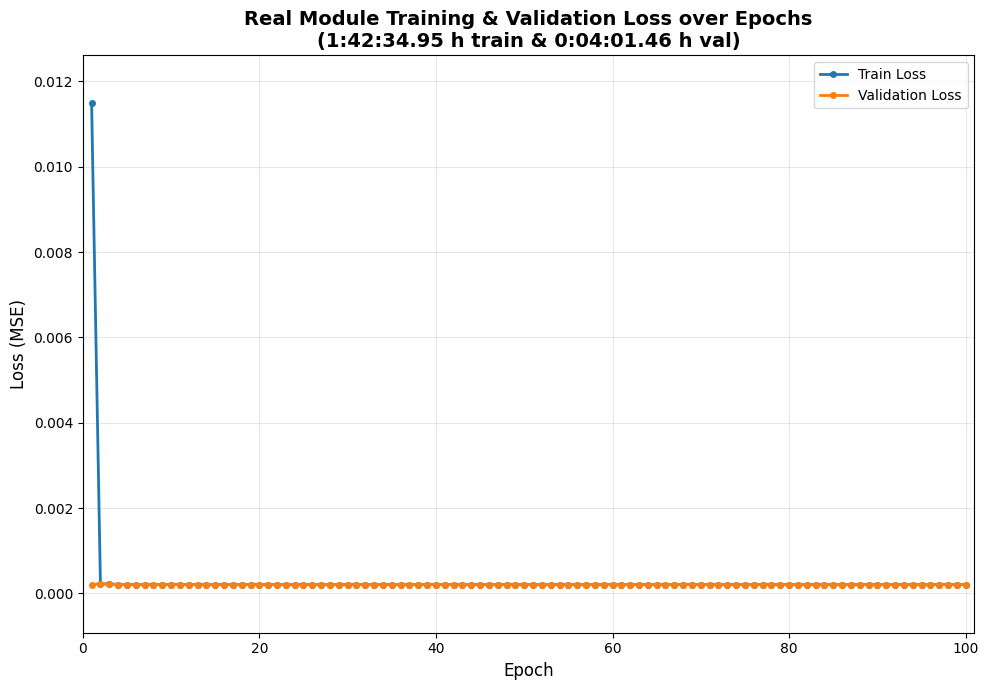

Real Module | Epoch 1/100 | Train Loss: 0.011482 | Val Loss 0.000208 | Time: 116.36 seconds
Real Module | Epoch 2/100 | Train Loss: 0.000220 | Val Loss 0.000224 | Time: 70.68 seconds
Real Module | Epoch 3/100 | Train Loss: 0.000227 | Val Loss 0.000216 | Time: 78.77 seconds
Real Module | Epoch 4/100 | Train Loss: 0.000208 | Val Loss 0.000207 | Time: 67.86 seconds
Real Module | Epoch 5/100 | Train Loss: 0.000207 | Val Loss 0.000207 | Time: 57.94 seconds
Real Module | Epoch 6/100 | Train Loss: 0.000207 | Val Loss 0.000207 | Time: 61.22 seconds
Real Module | Epoch 7/100 | Train Loss: 0.000207 | Val Loss 0.000207 | Time: 60.97 seconds
Real Module | Epoch 8/100 | Train Loss: 0.000207 | Val Loss 0.000207 | Time: 60.44 seconds
Real Module | Epoch 9/100 | Train Loss: 0.000207 | Val Loss 0.000207 | Time: 60.08 seconds
Real Module | Epoch 10/100 | Train Loss: 0.000207 | Val Loss 0.000207 | Time: 60.37 seconds
Real Module | Epoch 11/100 | Train Loss: 0.000207 | Val Loss 0.000207 | Time: 60.07 seco

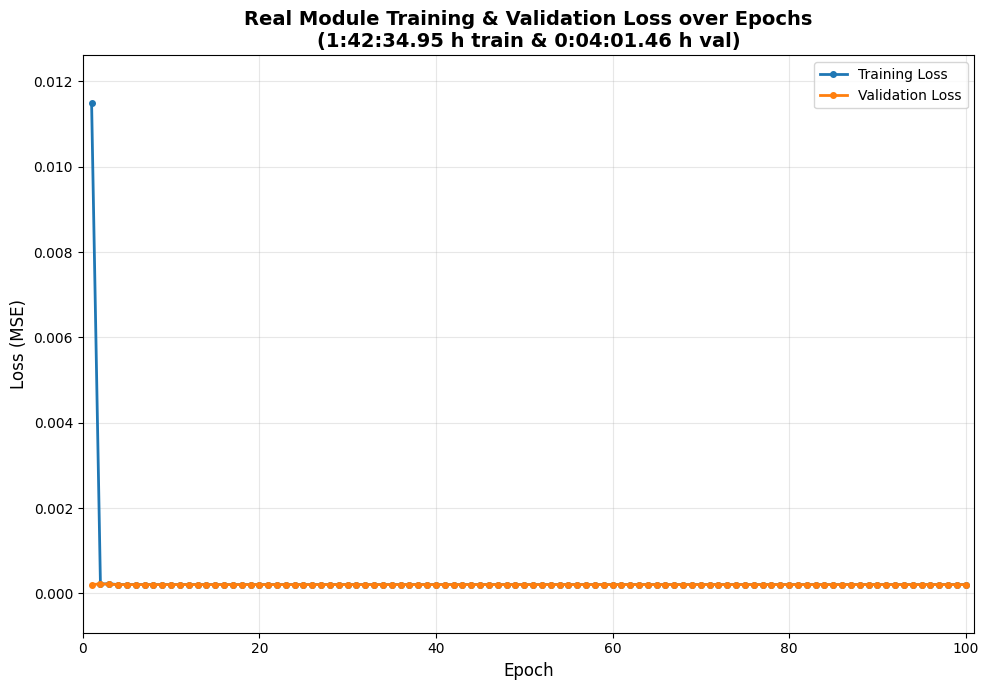

In [10]:
print("--- Starting Training for the Real NN Module ---")
train_loss_history = []  # Track losses for graphing
val_loss_history = []
log_lines = []
total_time = 0
train_time = 0
val_time = 0

# ! if using .compile(), it is expected for the first epoch to take longer
for epoch in range(1, epochs + 1):
    start = time.time()
    epoch_train_loss = 0.0

    # Training
    New_Re_NN.train()
    for X_batch, Y_batch in train_loader_real_new:
        # Transfer data to GPU if possible
        X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)

        # MEMORYLESS RESHAPE: Flatten into a 1D column
        X_batch_flat = X_batch.view(-1, 1)
        Y_batch_flat = Y_batch.view(-1, 1)

        # L-BFGS and LM require a "closure" function to recalculate the loss, but for LM it is often required to return the unreduced residuals
        def closure():
            optimizer_real_new.zero_grad(set_to_none=True)
            predictions = New_Re_NN(X_batch_flat)

            loss = criterion(predictions, Y_batch_flat)
            loss.backward()
            return loss
        # Pass the closure to the optimizer
        optimizer_real_new.step(closure)
        # To track the loss for your graphs, you have to call it once outside
        epoch_train_loss += closure().item()

    avg_train_loss = epoch_train_loss / len(train_loader_real_new)
    train_loss_history.append(avg_train_loss)  # Store loss for this epoch

    middle = time.time()

    # Validation
    New_Re_NN.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for X_val, Y_val in val_loader_real_new:
            X_val, Y_val = X_val.to(device, non_blocking=True), Y_val.to(device, non_blocking=True)
            predictions = New_Re_NN(X_val.view(-1, 1))
            val_loss = criterion(predictions, Y_val.view(-1, 1))
            epoch_val_loss += val_loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader_real_new)
    val_loss_history.append(avg_val_loss)

    end = time.time()

    train_time += middle - start
    val_time += end - middle
    total_time += end - start
    line = f'Real Module | Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss {avg_val_loss:.6f} | Time: {end - start:.2f} seconds'
    log_lines.append(line)

    if epoch % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(10, 7))
        plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Train Loss")
        plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Validation Loss")
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss (MSE)', fontsize=12)
        plt.legend()
        plt.title(f'Real Module Training & Validation Loss over Epochs\n({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} h train & {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} h val)', fontsize=14, fontweight='bold')
        plt.xlim(0, epochs + 1)
        margin = (max(train_loss_history) - min(train_loss_history)) * 0.1 if len(train_loss_history) > 1 else 0.1
        plt.ylim(min(train_loss_history) - margin, max(train_loss_history) + margin)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(*log_lines, sep='\n')
    else:
        print(line)


print(f'Real NN Module Training Complete in {int(total_time // 3600)}:{int(total_time // 60 % 60):02}:{total_time % 60:05.2f} hours! ({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} hours in training and {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} hours in validation)')

# Plot loss vs epoch
plt.figure(figsize=(10, 7))
plt.plot(range(1, epochs + 1), train_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Training Loss")
plt.plot(range(1, epochs + 1), val_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Validation Loss")
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.title(f'Real Module Training & Validation Loss over Epochs\n({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} h train & {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} h val)', fontsize=14, fontweight='bold')
plt.xlim(0, epochs + 1)
margin = (max(train_loss_history) - min(train_loss_history)) * 0.1
plt.ylim(min(train_loss_history) - margin, max(train_loss_history) + margin)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(relev_dir, f"new_method_real_loss.png"), dpi=150)
plt.show()

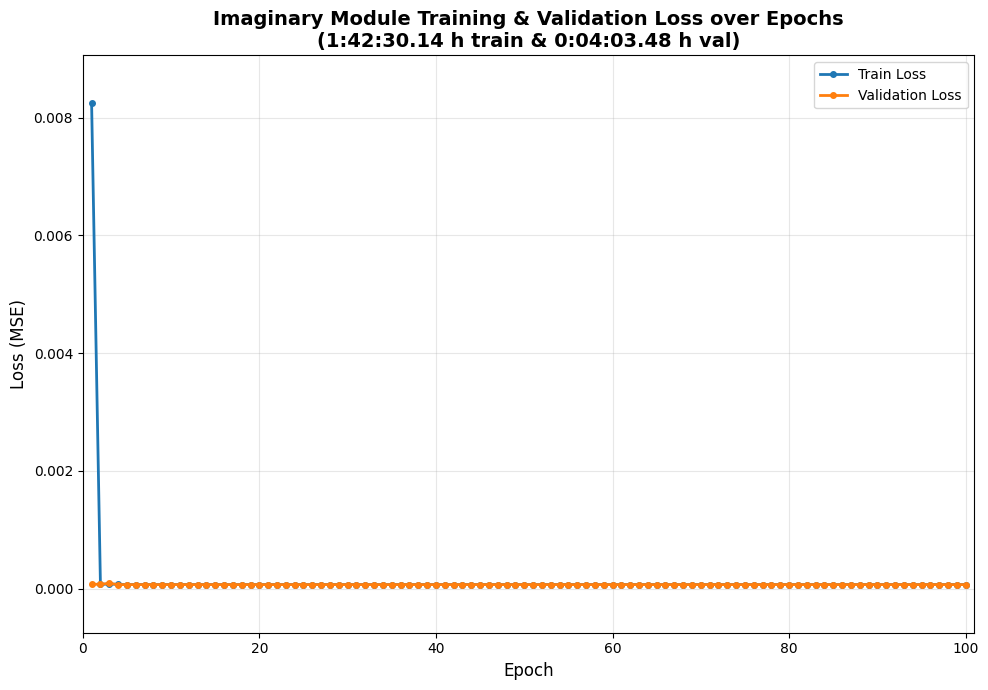

Imaginary Module | Epoch 1/100 | Train Loss: 0.008242 | Val Loss 0.000077 | Time: 119.93 seconds
Imaginary Module | Epoch 2/100 | Train Loss: 0.000072 | Val Loss 0.000075 | Time: 71.16 seconds
Imaginary Module | Epoch 3/100 | Train Loss: 0.000082 | Val Loss 0.000092 | Time: 71.96 seconds
Imaginary Module | Epoch 4/100 | Train Loss: 0.000073 | Val Loss 0.000070 | Time: 71.43 seconds
Imaginary Module | Epoch 5/100 | Train Loss: 0.000070 | Val Loss 0.000070 | Time: 61.95 seconds
Imaginary Module | Epoch 6/100 | Train Loss: 0.000070 | Val Loss 0.000070 | Time: 62.77 seconds
Imaginary Module | Epoch 7/100 | Train Loss: 0.000070 | Val Loss 0.000070 | Time: 62.22 seconds
Imaginary Module | Epoch 8/100 | Train Loss: 0.000070 | Val Loss 0.000070 | Time: 62.62 seconds
Imaginary Module | Epoch 9/100 | Train Loss: 0.000070 | Val Loss 0.000070 | Time: 61.27 seconds
Imaginary Module | Epoch 10/100 | Train Loss: 0.000070 | Val Loss 0.000070 | Time: 69.42 seconds
Imaginary Module | Epoch 11/100 | Trai

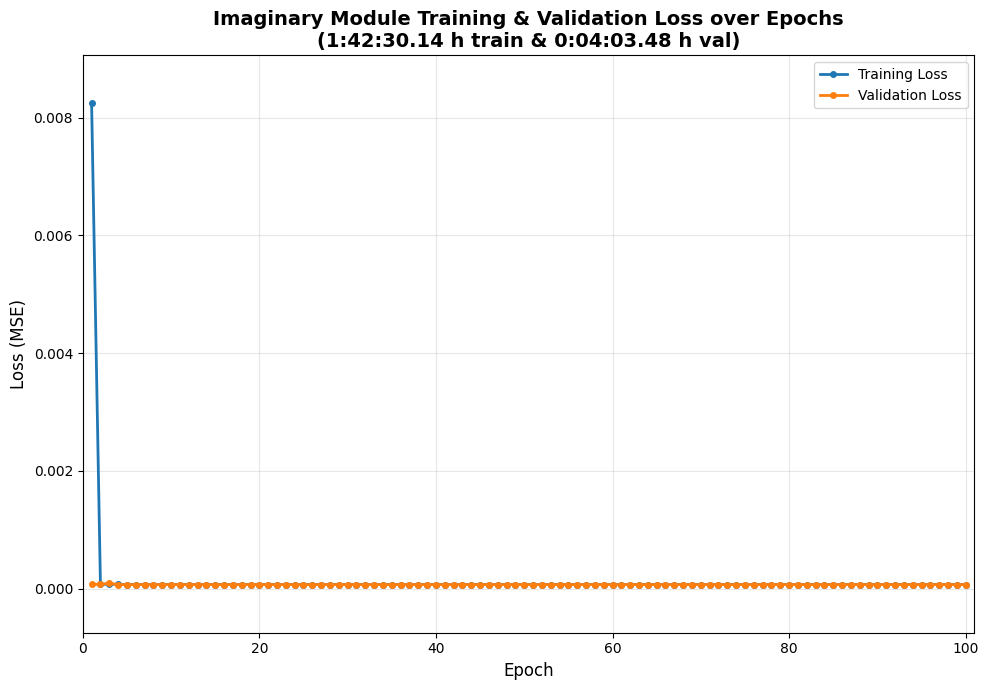

In [11]:
print("--- Starting Training for the Imaginary NN Module ---")
train_loss_history = []  # Track losses for graphing
val_loss_history = []
log_lines = []
total_time = 0
train_time = 0
val_time = 0

for epoch in range(1, epochs + 1):
    start = time.time()

    # Training
    New_Im_NN.train()
    epoch_train_loss = 0.0
    for X_batch, Y_batch in train_loader_imag_new:
        # Transfer data to GPU if possible
        X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)

        # MEMORYLESS RESHAPE: Flatten into a 1D column
        X_batch_flat = X_batch.view(-1, 1)
        Y_batch_flat = Y_batch.view(-1, 1)

        # L-BFGS and LM require a "closure" function to recalculate the loss, but for LM it is often required to return the unreduced residuals
        def closure():
            optimizer_imag_new.zero_grad(set_to_none=True)
            predictions = New_Im_NN(X_batch_flat)

            loss = criterion(predictions, Y_batch_flat)
            loss.backward()
            return loss
        # Pass the closure to the optimizer
        optimizer_imag_new.step(closure)
        # To track the loss for your graphs, you have to call it once outside
        epoch_train_loss += closure().item()

    avg_train_loss = epoch_train_loss / len(train_loader_imag_new)
    train_loss_history.append(avg_train_loss)  # Store loss for this epoch

    middle = time.time()

    # Validation
    New_Im_NN.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for X_val, Y_val in val_loader_imag_new:
            X_val, Y_val = X_val.to(device, non_blocking=True), Y_val.to(device, non_blocking=True)
            predictions = New_Im_NN(X_val.view(-1, 1))
            val_loss = criterion(predictions, Y_val.view(-1, 1))
            epoch_val_loss += val_loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader_imag_new)
    val_loss_history.append(avg_val_loss)

    end = time.time()

    train_time += middle - start
    val_time += end - middle
    total_time += end - start
    line = f'Imaginary Module | Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss {avg_val_loss:.6f} | Time: {end - start:.2f} seconds'
    log_lines.append(line)

    if epoch % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(10, 7))
        plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Train Loss")
        plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Validation Loss")
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss (MSE)', fontsize=12)
        plt.legend()
        plt.title(f'Imaginary Module Training & Validation Loss over Epochs\n({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} h train & {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} h val)', fontsize=14, fontweight='bold')
        plt.xlim(0, epochs + 1)
        margin = (max(train_loss_history) - min(train_loss_history)) * 0.1 if len(train_loss_history) > 1 else 0.1
        plt.ylim(min(train_loss_history) - margin, max(train_loss_history) + margin)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(*log_lines, sep='\n')
    else:
        print(line)


print(f'Imaginary NN Module Training Complete in {int(total_time // 3600)}:{int(total_time // 60 % 60):02}:{total_time % 60:05.2f} hours! ({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} hours in training and {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} hours in validation)')

# Plot loss vs epoch
plt.figure(figsize=(10, 7))
plt.plot(range(1, epochs + 1), train_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Training Loss")
plt.plot(range(1, epochs + 1), val_loss_history, marker='o', linestyle='-', linewidth=2, markersize=4, label="Validation Loss")
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.title(f'Imaginary Module Training & Validation Loss over Epochs\n({int(train_time // 3600)}:{int(train_time // 60 % 60):02}:{train_time % 60:05.2f} h train & {int(val_time // 3600)}:{int(val_time // 60 % 60):02}:{val_time % 60:05.2f} h val)', fontsize=14, fontweight='bold')
plt.xlim(0, epochs + 1)
margin = (max(train_loss_history) - min(train_loss_history)) * 0.1
plt.ylim(min(train_loss_history) - margin, max(train_loss_history) + margin)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(relev_dir, f"new_method_imag_loss.png"), dpi=150)
plt.show()

In [12]:
# Create dictionaries containing both the weights and the global limits

X_min, X_max = X_r_limits
Y_min, Y_max = Y_r_limits
checkpoint_re = {
    'model_state_dict': New_Re_NN.state_dict(),
    'X_min': X_min, 'X_max': X_max,
    'Y_min': Y_min, 'Y_max': Y_max
}

X_min, X_max = X_i_limits
Y_min, Y_max = Y_i_limits
checkpoint_im = {
    'model_state_dict': New_Im_NN.state_dict(),
    'X_min': X_min, 'X_max': X_max,
    'Y_min': Y_min, 'Y_max': Y_max
}

# Save the bundled checkpoints
torch.save(checkpoint_re, os.path.join(relev_dir, f"new_method_weights_limits_re.pth"))
torch.save(checkpoint_im, os.path.join(relev_dir, f"new_method_weights_limits_im.pth"))
print("Models and Global Normalization limits successfully bundled and saved.")


Training complete and weights saved!
Models and Global Normalization limits successfully bundled and saved.
